In [1]:
import os
import random
import zipfile
from pathlib import Path
import kagglehub
from sklearn.model_selection import train_test_split
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import keras.backend as K
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation , GlobalAveragePooling2D ,DepthwiseConv2D ,Input ,Add ,Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import ReLU, LeakyReLU
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping , LearningRateScheduler
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:

from pathlib import Path
import random
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)




import kagglehub
DATASET_DOWNLOAD_PATH = kagglehub.dataset_download(
    "mohamedhanyyy/chest-ctscan-images"
)

print("Downloaded dataset location:", DATASET_DOWNLOAD_PATH)




def find_dataset_split_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]

    for p in candidates:
        names = {x.name.lower() for x in p.iterdir() if x.is_dir()}
        if {"train", "test", "valid"}.issubset(names):
            return p

    raise FileNotFoundError(
        "Could not find a directory containing train/, test/, and valid/ "
        f"inside {root}."
    )

source_root = find_dataset_split_root(DATASET_DOWNLOAD_PATH)
original_train_dir = source_root / "train"
original_test_dir = source_root / "test"
original_valid_dir = source_root / "valid"

print("Source root:", source_root)


















CLASS_MAP = {
    "adenocarcinoma": "adenocarcinoma",
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib": "adenocarcinoma",
    "large.cell.carcinoma": "large.cell.carcinoma",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa": "large.cell.carcinoma",
    "normal": "normal",
    "squamous.cell.carcinoma": "squamous.cell.carcinoma",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa": "squamous.cell.carcinoma",
}


class_names = [
    "adenocarcinoma",
    "large.cell.carcinoma",
    "squamous.cell.carcinoma",
    "normal",
]

NUM_CLASSES = len(class_names)

print("\nSource-folder -> final-class mapping:")
for source_class, final_class in CLASS_MAP.items():
    print(f"  {source_class}  -->  {final_class}")

print("\nFinal classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")
print("Final number of classes:", NUM_CLASSES)

if NUM_CLASSES != 4:
    raise RuntimeError(f"Internal class configuration error: expected 4, got {NUM_CLASSES}")






valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
all_images = []

for split_dir in [original_train_dir, original_test_dir, original_valid_dir]:
    for source_class_dir in split_dir.iterdir():
        if not source_class_dir.is_dir():
            continue

        source_class = source_class_dir.name

        if source_class not in CLASS_MAP:
            raise ValueError(
                f"Unexpected class folder found: '{source_class}' in {split_dir}. "
                f"Expected one of: {sorted(CLASS_MAP)}"
            )

        final_class = CLASS_MAP[source_class]

        for file_path in source_class_dir.iterdir():
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                all_images.append((str(file_path), final_class, source_class))

if not all_images:
    raise RuntimeError("No image files were found in the downloaded dataset.")




rng = random.Random(RANDOM_STATE)
rng.shuffle(all_images)

labels = [label for _, label, _ in all_images]






train_data, temp_data = train_test_split(
    all_images,
    test_size=0.40,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=labels
)

temp_labels = [label for _, label, _ in temp_data]

valid_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=temp_labels
)

print("FINAL DATA SPLIT")
print(f"Total images: {len(all_images)}")
print(f"Train       : {len(train_data)} ({len(train_data)/len(all_images)*100:.2f}%)")
print(f"Validation  : {len(valid_data)} ({len(valid_data)/len(all_images)*100:.2f}%)")
print(f"Test        : {len(test_data)} ({len(test_data)/len(all_images)*100:.2f}%)")




base_dir = Path("/content/ct-scan-60-20-20")
train_dir = base_dir / "train"
valid_dir = base_dir / "valid"
test_dir = base_dir / "test"

if base_dir.exists():
    shutil.rmtree(base_dir)

for split_dir in [train_dir, valid_dir, test_dir]:
    for class_name in class_names:
        (split_dir / class_name).mkdir(parents=True, exist_ok=True)






def copy_images(data, destination_dir):
    for source_path, final_class, source_class in data:
        source_path = Path(source_path)
        safe_source = source_class.replace("/", "_").replace("\\", "_")
        destination_name = f"{safe_source}__{source_path.name}"
        destination_path = destination_dir / final_class / destination_name
        shutil.copy2(source_path, destination_path)

copy_images(train_data, train_dir)
copy_images(valid_data, valid_dir)
copy_images(test_data, test_dir)




for split_name, split_dir in [("train", train_dir), ("valid", valid_dir), ("test", test_dir)]:
    detected = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    expected = sorted(class_names)

    if detected != expected:
        raise ValueError(
            f"{split_name} folder classes do not match the four-class setup.\n"
            f"Expected: {expected}\n"
            f"Found:    {detected}"
        )

print("\nCreated dataset:", base_dir)
print("Final classes:", class_names)
print("Final class count:", NUM_CLASSES)
print("\n✓ The 7 source folders have been correctly merged into 4 classes.")
print("✓ All original images were combined, shuffled, and stratified into 60/20/20.")


Using Colab cache for faster access to the 'chest-ctscan-images' dataset.
Downloaded dataset location: /kaggle/input/chest-ctscan-images
Source root: /kaggle/input/chest-ctscan-images/Data

Source-folder -> final-class mapping:
  adenocarcinoma  -->  adenocarcinoma
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib  -->  adenocarcinoma
  large.cell.carcinoma  -->  large.cell.carcinoma
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa  -->  large.cell.carcinoma
  normal  -->  normal
  squamous.cell.carcinoma  -->  squamous.cell.carcinoma
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa  -->  squamous.cell.carcinoma

Final classes:
  0: adenocarcinoma
  1: large.cell.carcinoma
  2: squamous.cell.carcinoma
  3: normal
Final number of classes: 4
FINAL DATA SPLIT
Total images: 1000
Train       : 600 (60.00%)
Validation  : 200 (20.00%)
Test        : 200 (20.00%)

Created dataset: /content/ct-scan-60-20-20
Final classes: ['adenocarcinoma', 'large.cell.carcinoma', 'squamous.cell.carcinoma', 'normal'

In [3]:
train_datagen = ImageDataGenerator(







)

In [4]:
valid_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

Found 579 images belonging to 4 classes.


In [6]:
validation_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 200 images belonging to 4 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 196 images belonging to 4 classes.


In [8]:
os.makedirs(test_dir, exist_ok=True)


In [9]:

test_files = os.listdir(test_dir)
print("Number of files in test directory:", len(test_files))

Number of files in test directory: 4


In [10]:
print("Test directory:", test_dir)


Test directory: /content/ct-scan-60-20-20/test


In [11]:
def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2 * (precision * recall) / (precision + recall + K.epsilon())
    return f1_val

In [12]:
METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
    f1_score
]


In [13]:

input_layer = Input(shape=(224, 224, 3))


x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)


x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)


block3_output = Conv2D(96, (3,3), activation='relu', padding='same')(x)
block3_output = BatchNormalization()(block3_output)
block3_output = MaxPooling2D((2, 2))(block3_output)


x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(block3_output)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
block4_branch = Conv2D(64, (1,1), activation='relu', padding='same')(x)
x = Conv2D(160, (3, 3), activation='relu', padding='same')(block4_branch)
x = BatchNormalization()(x)
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
block4_output = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(block4_output)


x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
x = Conv2D(192, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(96, (1,1), activation='relu', padding='same')(x)
x = Conv2D(224, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)


main_branch_output = MaxPooling2D((2, 2))(x)
main_branch_output = BatchNormalization()(main_branch_output)

x = GlobalAveragePooling2D()(main_branch_output)


output_layer = Dense(4, activation='softmax')(x)


model = Model(inputs=input_layer, outputs=output_layer)


model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 28, 28, 96)     │           960 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 160)    │        92,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 28, 28, 160)    │         1,600 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 28, 28, 160)    │         1,600 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_3              │ (None, 14, 14, 160)    │         1,600 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 790,660 (3.02 MB)

 Trainable params: 788,420 (3.01 MB)

 Non-trainable params: 2,240 (8.75 KB)



In [14]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image
plot_model(model, to_file='convnet.png', show_shapes=True,show_layer_names=True)
Image(filename='convnet.png')

In [15]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=METRICS
)

In [16]:
def lr_schedule(epoch,learning_rate):
  if epoch <7:
    return learning_rate
  else:
    return 0.95*learning_rate

lr_scheduler = LearningRateScheduler(lr_schedule)

In [17]:
callbacks = [
    ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)

]

In [21]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    true_positives = tf.reduce_sum(y_true * y_pred)
    possible_positives = tf.reduce_sum(y_true)
    predicted_positives = tf.reduce_sum(y_pred)

    precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
    recall = true_positives / (possible_positives + tf.keras.backend.epsilon())

    return 2.0 * precision * recall / (precision + recall + tf.keras.backend.epsilon())

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.0005),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
        f1_score
    ]
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=35,
    callbacks=[checkpoint, lr_scheduler],
    verbose=1
)

Epoch 1/35
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5027 - auc: 0.7952 - f1_score: 0.2905 - loss: 1.0792 - precision: 0.8340 - recall: 0.1759
Epoch 1: val_accuracy improved from None to 0.33500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 32s 449ms/step - accuracy: 0.5043 - auc: 0.8043 - f1_score: 0.2946 - loss: 1.0574 - precision: 0.7939 - recall: 0.1796 - val_accuracy: 0.3350 - val_auc: 0.5717 - val_f1_score: 0.0000e+00 - val_loss: 1.3694 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/35
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5226 - auc: 0.8253 - f1_score: 0.4117 - loss: 1.0017 - precision: 0.7462 - recall: 0.2915
Epoch 2: val_accuracy did not improve from 0.33500
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - accuracy: 0.5389 - auc: 0.8315 - f1_score: 0.4215 - loss: 0.9856 - precision: 0.7364 - recall: 0.3040 - val_accuracy: 0.3350 - val_auc: 0.5717 

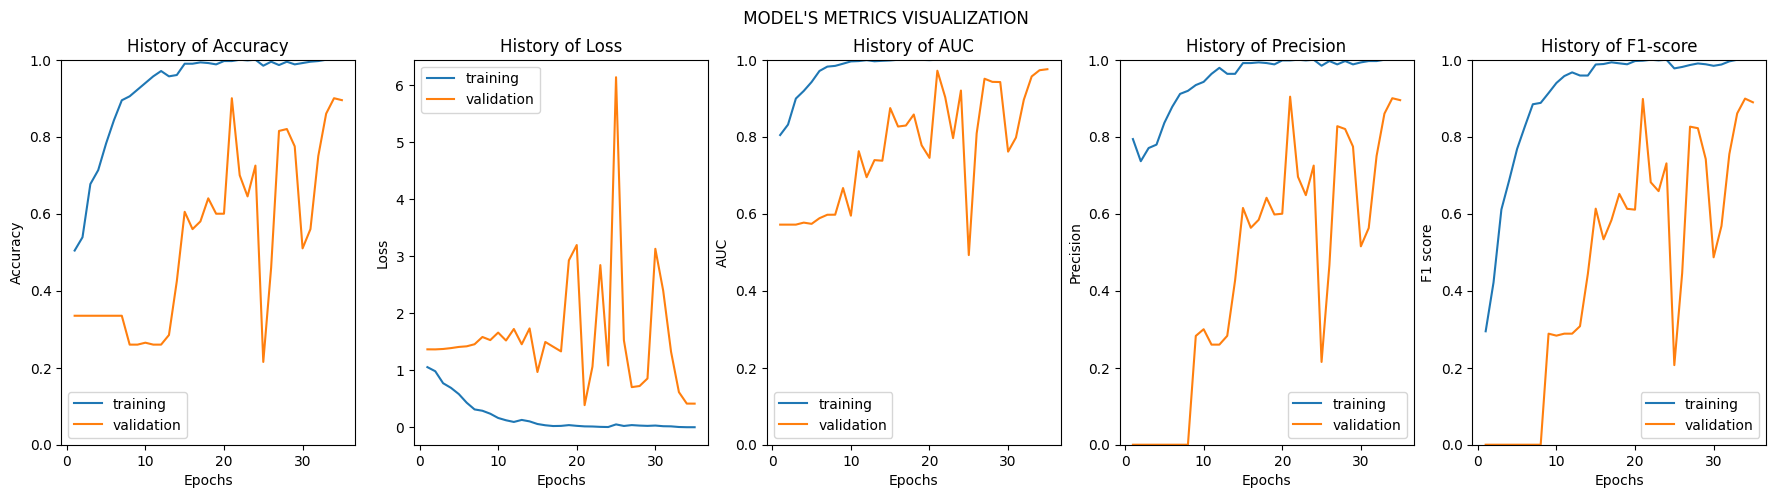

In [22]:
def Train_Val_Plot(acc, val_acc, loss, val_loss, auc, val_auc, precision, val_precision, f1, val_f1):

    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")


    rescale_factor = 0

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim([0, 1.0])
    ax1.legend(['training', 'validation'])

    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])

    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.set_ylim([rescale_factor, 1.0])
    ax3.legend(['training', 'validation'])

    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.set_ylim([rescale_factor, 1.0])
    ax4.legend(['training', 'validation'])

    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.set_ylim([rescale_factor, 1.0])
    ax5.legend(['training', 'validation'])

    plt.show()


Train_Val_Plot(history.history['accuracy'], history.history['val_accuracy'],
               history.history['loss'], history.history['val_loss']
               ,
               history.history['auc'], history.history['val_auc'],
               history.history['precision'], history.history['val_precision'],
               history.history['f1_score'], history.history['val_f1_score'])


In [23]:
model.evaluate(test_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.9337 - auc: 0.9888 - f1_score: 0.9204 - loss: 0.2423 - precision: 0.9333 - recall: 0.9286


[0.24228128790855408,
 0.9336734414100647,
 0.9333333373069763,
 0.9285714030265808,
 0.9887981414794922,
 0.9204404354095459]

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step
                         precision    recall  f1-score   support

         adenocarcinoma     0.9242    0.8971    0.9104        68
   large.cell.carcinoma     0.8537    0.9459    0.8974        37
                 normal     0.9750    1.0000    0.9873        39
squamous.cell.carcinoma     0.9796    0.9231    0.9505        52

               accuracy                         0.9337       196
              macro avg     0.9331    0.9415    0.9364       196
           weighted avg     0.9357    0.9337    0.9339       196

Overall Accuracy: 0.9337


,precision,recall,f1-score,support
adenocarcinoma,0.9242,0.8971,0.9104,68.0000
large.cell.carcinoma,0.8537,0.9459,0.8974,37.0000
normal,0.9750,1.0000,0.9873,39.0000
squamous.cell.carcinoma,0.9796,0.9231,0.9505,52.0000
accuracy,0.9337,0.9337,0.9337,0.9337
macro avg,0.9331,0.9415,0.9364,196.0000
weighted avg,0.9357,0.9337,0.9339,196.0000


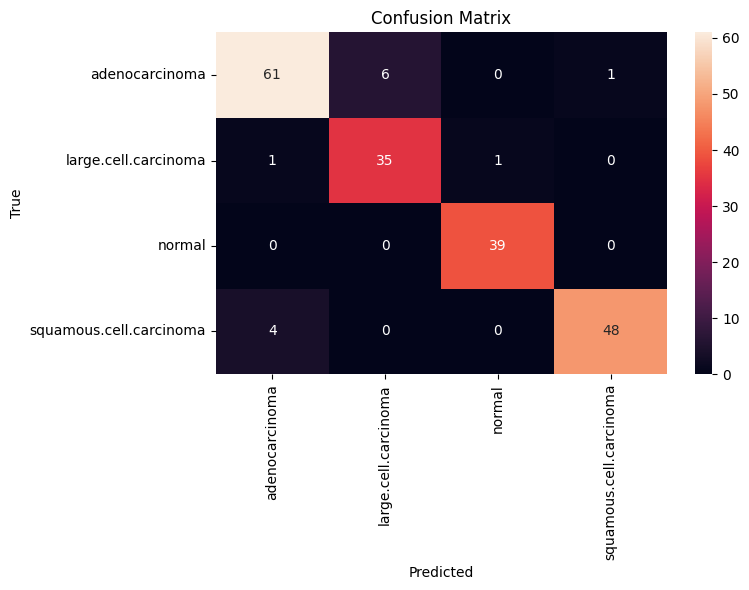

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

test_generator.reset()

y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

class_indices = test_generator.class_indices
class_names = [name for name, index in sorted(class_indices.items(), key=lambda item: item[1])]
num_classes = test_generator.num_classes

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")

report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(num_classes),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).T.round(4)

display(report_df)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

plt.figure(figsize=(8, 6))
sn.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
